# 11.2 · Opening and closing

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain opening and closing using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[05 · Image Processing](../../05-image-processing/README.md), [08 · Color Spaces](../../08-color-spaces/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Morphology processes shape using a small structuring element. Imagine moving a stencil across a binary mask and asking whether any or all covered pixels are foreground. This provides controllable ways to remove specks, fill gaps and outline regions.

## 2. Intuition

Opening is erosion followed by dilation; it removes small foreground structures. Closing reverses the order and can fill narrow background gaps. Applying an operation repeatedly changes the effective scale. These operations alter measurements, so cleaning a mask before area estimation needs a documented policy.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 11
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
(A\ominus B)(p)=\bigwedge_{b\in B}A(p+b)
$$

A is a Boolean image, B the active stencil offsets, p the current pixel, and ∧ means all entries must be true. For a 3×3 all-foreground patch, erosion returns true; one missing entry makes it false.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
patch = np.ones((3, 3), dtype=bool)
assert patch.all()
patch[0, 0] = False
eroded_center = patch.all()
dilated_center = patch.any()
print(eroded_center, dilated_center)

False True


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The reference pads with false, scans square windows and evaluates all or any. OpenCV performs optimized morphology; border settings must match to compare edges.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def morphology_lab(lesson, seed, amount):
    mask = shapes() > 0
    rng = np.random.default_rng(seed)
    noisy = mask.copy()
    noise = rng.random(mask.shape)
    noisy[noise < 0.02 * amount] = True
    noisy[noise > 1 - 0.02 * amount] = False
    eroded = n.morphology(noisy, 3, "erode")
    dilated = n.morphology(noisy, 3, "dilate")
    output = n.morphology(eroded, 3, "dilate") if lesson == 0 else n.morphology(dilated, 3, "erode")
    if lesson == 2:
        output = dilated & ~eroded
    return Result(
        "11 · Morphology and structuring elements",
        {
            "Clean mask": mask,
            "Noise": noisy,
            "Erosion": eroded,
            "Dilation": dilated,
            "Opening / closing / gradient": output,
        },
        metrics={"foreground_before": int(noisy.sum()), "foreground_after": int(output.sum())},
    )

{
  "foreground_before": 1986,
  "foreground_after": 2073
}



## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import morphology

display(Code(inspect.getsource(morphology), language="python"))

def morphology(mask, size=3, operation="erode"):
    """Binary square erosion/dilation with false values outside the image."""
    if size < 1 or size % 2 == 0 or operation not in {"erode", "dilate"}:
        raise ValueError("Use odd size and erode/dilate.")
    mask = np.asarray(mask, bool)
    pad = size // 2
    padded = np.pad(mask, pad, mode="constant")
    out = np.zeros_like(mask)
    for y in range(mask.shape[0]):
        for x in range(mask.shape[1]):
            patch = padded[y : y + size, x : x + size]
            out[y, x] = patch.all() if operation == "erode" else patch.any()
    return out

## 8. Experiment

Try a horizontal line stencil on broken text and compare it with a square stencil. Measure whether neighboring letters incorrectly merge.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "foreground_before": 1986,
    "foreground_after": 2073
  },
  "second_seed": {
    "foreground_before": 2011,
    "foreground_after": 2098
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

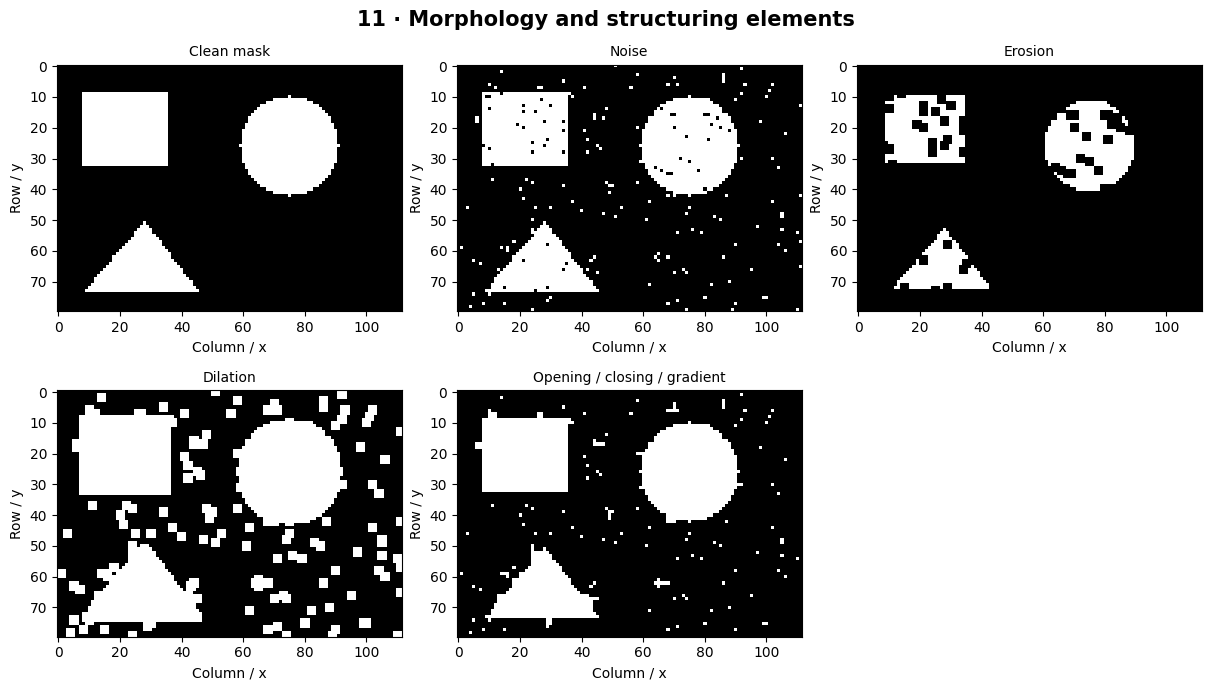

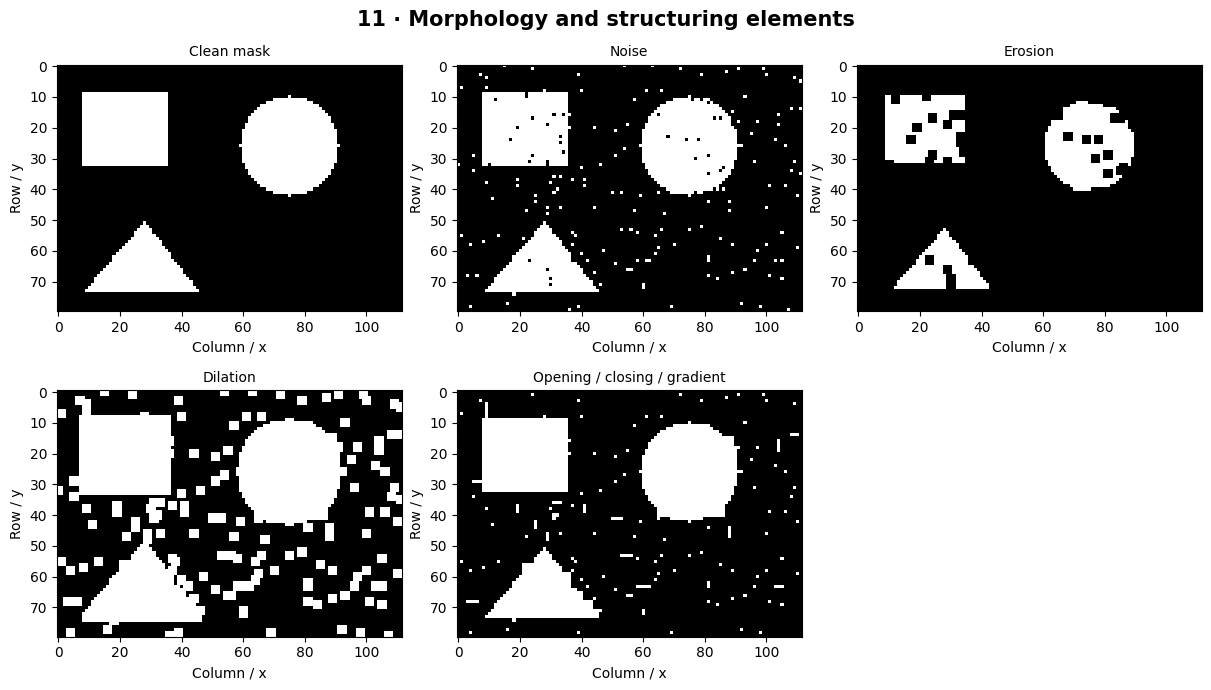

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Document Cleanup Pipeline**. Clean binary masks without destroying useful structure. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Opening can delete legitimate thin lines. The structuring element size should reflect object scale, not an arbitrary constant copied from another image.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Try a horizontal line stencil on broken text and compare it with a square stencil. Measure whether neighboring letters incorrectly merge.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Create a document cleanup pipeline that removes isolated noise while preserving narrow strokes, with before/after component statistics.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Opening is erosion followed by dilation; it removes small foreground structures. Closing reverses the order and can fill narrow background gaps. Applying an operation repeatedly changes the effective scale. These operations alter measurements, so cleaning a mask before area estimation needs a documented policy.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Gradients, top-hat and black-hat** in this chapter.

[Primary reference](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)